In [1]:
import numpy as np
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm

# 1. 加载 Fashion-MNIST 数据集并转为 NumPy
def load_fashion_mnist(batch_size=64, root='./data'):
    transform = transforms.Compose([transforms.ToTensor()])
    train_dataset = torchvision.datasets.FashionMNIST(root=root, train=True, download=True, transform=transform)
    test_dataset = torchvision.datasets.FashionMNIST(root=root, train=False, download=True, transform=transform)
    
    # 转换为 NumPy 数组并调整形状: (N, 784), 像素值范围 [0,1]
    X_train = train_dataset.data.numpy().reshape(-1, 784) / 255.0
    y_train = train_dataset.targets.numpy()
    X_test = test_dataset.data.numpy().reshape(-1, 784) / 255.0
    y_test = test_dataset.targets.numpy()
    
    # 生成小批量索引
    def batches(X, y, batch_size):
        n_samples = X.shape[0]
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        for start in range(0, n_samples, batch_size):
            end = min(start + batch_size, n_samples)
            batch_idx = indices[start:end]
            yield X[batch_idx], y[batch_idx]
    
    return (X_train, y_train), (X_test, y_test), batches

# 2. 参数初始化 (正态分布，标准差 0.01)
def init_params(input_size, hidden_size, output_size):
    np.random.seed(42)
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))
    return W1, b1, W2, b2

# 3. ReLU 激活函数
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

# 4. Softmax 和交叉熵损失 (数值稳定版本)
def softmax(x):
    # x: (batch_size, n_classes)
    x_shifted = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x_shifted)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def cross_entropy_loss(pred_probs, y_true):
    # pred_probs: (batch_size, n_classes), y_true: (batch_size,) 整数标签
    batch_size = pred_probs.shape[0]
    log_probs = -np.log(pred_probs[np.arange(batch_size), y_true])
    loss = np.mean(log_probs)
    return loss

# 5. 前向传播
def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1      # (batch, hidden)
    A1 = relu(Z1)          # (batch, hidden)
    Z2 = A1 @ W2 + b2      # (batch, output)
    probs = softmax(Z2)    # (batch, output)
    return Z1, A1, Z2, probs

# 6. 反向传播 (手动梯度计算)
def backward(X, y_true, Z1, A1, Z2, probs, W2):
    batch_size = X.shape[0]
    # 损失对 Z2 的梯度: probs - one_hot(y_true)
    one_hot = np.zeros_like(probs)
    one_hot[np.arange(batch_size), y_true] = 1
    dZ2 = probs - one_hot                     # (batch, output)
    
    # 对 W2, b2 的梯度
    dW2 = (A1.T @ dZ2) / batch_size
    db2 = np.sum(dZ2, axis=0, keepdims=True) / batch_size
    
    # 对 A1 的梯度
    dA1 = dZ2 @ W2.T                         # (batch, hidden)
    
    # 对 Z1 的梯度 (ReLU 导数)
    dZ1 = dA1 * relu_derivative(Z1)          # (batch, hidden)
    
    # 对 W1, b1 的梯度
    dW1 = (X.T @ dZ1) / batch_size
    db1 = np.sum(dZ1, axis=0, keepdims=True) / batch_size
    
    return dW1, db1, dW2, db2

# 7. 训练循环
def train(X_train, y_train, X_test, y_test, batch_size, hidden_size, lr, epochs):
    input_size = X_train.shape[1]
    output_size = 10
    W1, b1, W2, b2 = init_params(input_size, hidden_size, output_size)
    
    # 准备小批量生成器
    _, _, batches = load_fashion_mnist(batch_size)  # 复用函数中的生成器逻辑
    # 重新定义生成器，因为上面 load_fashion_mnist 返回的是函数，需要传入数据
    def create_batches(X, y, batch_size):
        n = X.shape[0]
        indices = np.arange(n)
        np.random.shuffle(indices)
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            batch_idx = indices[start:end]
            yield X[batch_idx], y[batch_idx]
    
    train_losses = []
    test_accuracies = []
    
    for epoch in range(epochs):
        # 训练一个 epoch
        epoch_loss = 0
        n_batches = 0
        for X_batch, y_batch in create_batches(X_train, y_train, batch_size):
            # 前向传播
            Z1, A1, Z2, probs = forward(X_batch, W1, b1, W2, b2)
            # 损失
            loss = cross_entropy_loss(probs, y_batch)
            epoch_loss += loss
            n_batches += 1
            # 反向传播
            dW1, db1, dW2, db2 = backward(X_batch, y_batch, Z1, A1, Z2, probs, W2)
            # 更新参数 (SGD)
            W1 -= lr * dW1
            b1 -= lr * db1
            W2 -= lr * dW2
            b2 -= lr * db2
        
        avg_loss = epoch_loss / n_batches
        train_losses.append(avg_loss)
        
        # 测试集评估
        _, _, _, test_probs = forward(X_test, W1, b1, W2, b2)
        y_pred = np.argmax(test_probs, axis=1)
        test_acc = np.mean(y_pred == y_test)
        test_accuracies.append(test_acc)
        
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Test Acc: {test_acc:.4f}")
    
    return W1, b1, W2, b2, train_losses, test_accuracies

# 主程序
if __name__ == "__main__":
    # 超参数
    batch_size = 64
    hidden_size = 256
    learning_rate = 0.1
    epochs = 20
    
    # 加载数据
    (X_train, y_train), (X_test, y_test), _ = load_fashion_mnist(batch_size)
    
    # 训练模型
    W1, b1, W2, b2, losses, accs = train(
        X_train, y_train, X_test, y_test,
        batch_size, hidden_size, learning_rate, epochs
    )
    
    # 最终测试准确率
    _, _, _, test_probs = forward(X_test, W1, b1, W2, b2)
    y_pred_final = np.argmax(test_probs, axis=1)
    final_acc = np.mean(y_pred_final == y_test)
    print(f"\nFinal Test Accuracy: {final_acc:.4f}")

Epoch 1/20 - Loss: 0.6871 - Test Acc: 0.8120
Epoch 2/20 - Loss: 0.4453 - Test Acc: 0.8315
Epoch 3/20 - Loss: 0.3998 - Test Acc: 0.8527
Epoch 4/20 - Loss: 0.3731 - Test Acc: 0.8209
Epoch 5/20 - Loss: 0.3524 - Test Acc: 0.8627
Epoch 6/20 - Loss: 0.3361 - Test Acc: 0.8532
Epoch 7/20 - Loss: 0.3245 - Test Acc: 0.8521
Epoch 8/20 - Loss: 0.3126 - Test Acc: 0.8668
Epoch 9/20 - Loss: 0.3026 - Test Acc: 0.8736
Epoch 10/20 - Loss: 0.2939 - Test Acc: 0.8766
Epoch 11/20 - Loss: 0.2853 - Test Acc: 0.8744
Epoch 12/20 - Loss: 0.2780 - Test Acc: 0.8724
Epoch 13/20 - Loss: 0.2701 - Test Acc: 0.8756
Epoch 14/20 - Loss: 0.2642 - Test Acc: 0.8771
Epoch 15/20 - Loss: 0.2580 - Test Acc: 0.8701
Epoch 16/20 - Loss: 0.2522 - Test Acc: 0.8859
Epoch 17/20 - Loss: 0.2465 - Test Acc: 0.8827
Epoch 18/20 - Loss: 0.2411 - Test Acc: 0.8854
Epoch 19/20 - Loss: 0.2347 - Test Acc: 0.8844
Epoch 20/20 - Loss: 0.2293 - Test Acc: 0.8760

Final Test Accuracy: 0.8760


生成过拟合数据 (150样本, 50特征, 训练80, 验证70)...
训练集: 80 样本, 验证集: 70 样本


========== No Regularization ==========
Epoch  10 | Train Loss: 0.4392 | Val Loss: 0.5507
Epoch  20 | Train Loss: 0.3089 | Val Loss: 0.5584
Epoch  30 | Train Loss: 0.2005 | Val Loss: 0.5945
Epoch  40 | Train Loss: 0.1578 | Val Loss: 0.6255
Epoch  50 | Train Loss: 0.1188 | Val Loss: 0.6647
Epoch  60 | Train Loss: 0.0964 | Val Loss: 0.7035
Epoch  70 | Train Loss: 0.0799 | Val Loss: 0.7454
Epoch  80 | Train Loss: 0.0582 | Val Loss: 0.7859
Epoch  90 | Train Loss: 0.0540 | Val Loss: 0.8167
Epoch 100 | Train Loss: 0.0431 | Val Loss: 0.8562

========== Weight Decay (λ=0.01) ==========
Epoch  10 | Train Loss: 0.4294 | Val Loss: 0.5745
Epoch  20 | Train Loss: 0.2954 | Val Loss: 0.5804
Epoch  30 | Train Loss: 0.1999 | Val Loss: 0.6112
Epoch  40 | Train Loss: 0.1582 | Val Loss: 0.6467
Epoch  50 | Train Loss: 0.1087 | Val Loss: 0.6904
Epoch  60 | Train Loss: 0.0995 | Val Loss: 0.7208
Epoch  70 | Train Loss: 0.0703 | Val Loss: 0.7757
Epo

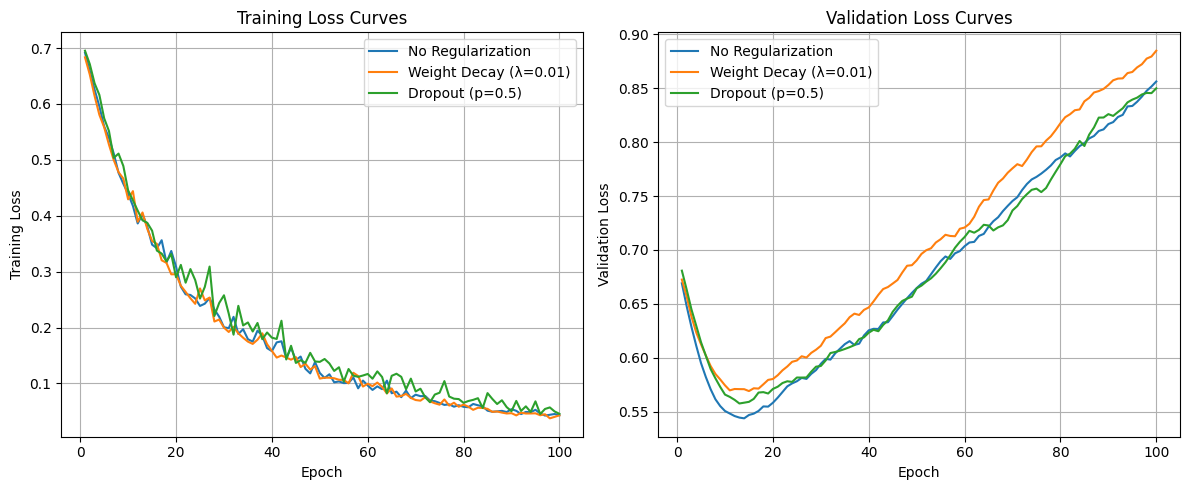


===== 最终验证损失 (100 epochs) =====
No Regularization        : 0.8562
Weight Decay (λ=0.01)    : 0.8848
Dropout (p=0.5)          : 0.8499


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# ========== 1. 修改后的 MLP 类（含 L2 和 Dropout）==========
class MLP:
    def __init__(self, input_dim, hidden_dim, output_dim,
                 l2_lambda=0.0, dropout_rate=0.0):
        self.l2_lambda = l2_lambda
        self.dropout_rate = dropout_rate

        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.01
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * 0.01
        self.b2 = np.zeros((1, output_dim))

        self.dropout_mask = None

    def _dropout(self, x, is_training):
        if not is_training or self.dropout_rate == 0:
            return x
        keep_prob = 1 - self.dropout_rate
        mask = (np.random.rand(*x.shape) < keep_prob) / keep_prob
        self.dropout_mask = mask
        return x * mask

    def forward(self, X, is_training=True):
        Z1 = X @ self.W1 + self.b1
        A1 = np.maximum(0, Z1)
        A1 = self._dropout(A1, is_training)

        Z2 = A1 @ self.W2 + self.b2
        shifted = Z2 - np.max(Z2, axis=1, keepdims=True)
        exp_z = np.exp(shifted)
        probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)

        self.cache = (X, Z1, A1, Z2, probs)
        return probs

    def backward(self, y_true):
        X, Z1, A1, Z2, probs = self.cache
        batch_size = X.shape[0]

        one_hot = np.zeros_like(probs)
        one_hot[np.arange(batch_size), y_true] = 1
        dZ2 = probs - one_hot

        dW2 = (A1.T @ dZ2) / batch_size
        db2 = np.sum(dZ2, axis=0, keepdims=True) / batch_size

        dA1 = dZ2 @ self.W2.T
        if self.dropout_mask is not None:
            dA1 = dA1 * self.dropout_mask

        dZ1 = dA1 * (Z1 > 0).astype(float)
        dW1 = (X.T @ dZ1) / batch_size
        db1 = np.sum(dZ1, axis=0, keepdims=True) / batch_size

        return dW1, db1, dW2, db2

    def update(self, grads, lr):
        dW1, db1, dW2, db2 = grads
        # 权重衰减: W = (1 - lr * l2_lambda) * W - lr * dW
        self.W1 = (1 - lr * self.l2_lambda) * self.W1 - lr * dW1
        self.W2 = (1 - lr * self.l2_lambda) * self.W2 - lr * dW2
        self.b1 -= lr * db1
        self.b2 -= lr * db2

# ========== 2. 生成过拟合数据 ==========
def generate_overfitting_data(n_samples=150, n_features=50, noise=0.2):
    X, y = make_classification(n_samples=n_samples, n_features=n_features,
                               n_informative=30, n_redundant=20,
                               n_clusters_per_class=1, flip_y=noise,
                               random_state=42)
    return X.astype(np.float32), y.astype(np.int64)

# ========== 3. 训练函数（每个 epoch 打印损失）==========
def train_model(model, X_train, y_train, X_val, y_val,
                batch_size=32, lr=0.01, epochs=100, verbose=True):
    n = X_train.shape[0]
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        idx = np.random.permutation(n)
        X_shuffle = X_train[idx]
        y_shuffle = y_train[idx]

        epoch_loss = 0
        n_batches = 0
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            X_batch = X_shuffle[start:end]
            y_batch = y_shuffle[start:end]

            probs = model.forward(X_batch, is_training=True)
            loss = -np.mean(np.log(probs[np.arange(len(y_batch)), y_batch]))
            epoch_loss += loss
            n_batches += 1

            grads = model.backward(y_batch)
            model.update(grads, lr)

        avg_train_loss = epoch_loss / n_batches
        train_losses.append(avg_train_loss)

        # 验证
        val_probs = model.forward(X_val, is_training=False)
        val_loss = -np.mean(np.log(val_probs[np.arange(len(y_val)), y_val]))
        val_losses.append(val_loss)

        if verbose and (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

# ========== 4. 对比实验 ==========
def run_comparison():
    print("生成过拟合数据 (150样本, 50特征, 训练80, 验证70)...")
    X, y = generate_overfitting_data(150, 50)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=70, random_state=42)
    print(f"训练集: {X_train.shape[0]} 样本, 验证集: {X_val.shape[0]} 样本\n")

    configs = {
        "No Regularization": {"l2": 0.0, "dropout": 0.0},
        "Weight Decay (λ=0.01)": {"l2": 0.01, "dropout": 0.0},
        "Dropout (p=0.5)": {"l2": 0.0, "dropout": 0.5},
    }

    results = {}
    for name, cfg in configs.items():
        print(f"\n========== {name} ==========")
        model = MLP(input_dim=50, hidden_dim=256, output_dim=2,
                    l2_lambda=cfg["l2"], dropout_rate=cfg["dropout"])
        train_loss, val_loss = train_model(model, X_train, y_train, X_val, y_val,
                                           batch_size=32, lr=0.01, epochs=100, verbose=True)
        results[name] = (train_loss, val_loss)

    # 绘制最终曲线
    plt.figure(figsize=(12, 5))
    epochs = range(1, 101)

    plt.subplot(1, 2, 1)
    for name, (train_loss, _) in results.items():
        plt.plot(epochs, train_loss, label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title("Training Loss Curves")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    for name, (_, val_loss) in results.items():
        plt.plot(epochs, val_loss, label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("Validation Loss Curves")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("l2_dropout_comparison.png")
    plt.show()

    # 打印最终验证损失
    print("\n===== 最终验证损失 (100 epochs) =====")
    for name, (_, val_loss) in results.items():
        print(f"{name:25s}: {val_loss[-1]:.4f}")

if __name__ == "__main__":
    run_comparison()

In [4]:
import torch
import torch.nn as nn
import torch.nn.init as init

# ------------------------------
# 辅助函数：构建深层网络
# ------------------------------
def build_deep_net(activation='sigmoid', init_method='normal', init_std=1.0):
    """
    构建一个 20 层的全连接网络，每层 256 个神经元，不含最后的输出层（仅特征提取）。
    activation: 'sigmoid' 或 'relu'
    init_method: 'normal' 或 'xavier'
    init_std: 仅当 init_method='normal' 时使用的标准差
    """
    layers = []
    for i in range(20):
        linear = nn.Linear(256, 256)   # 每层输入输出均为 256
        # 初始化权重
        if init_method == 'normal':
            init.normal_(linear.weight, mean=0.0, std=init_std)
        elif init_method == 'xavier':
            # Xavier 均匀初始化，增益根据激活函数选择：ReLU 使用 'relu' 增益 sqrt(2)
            init.xavier_uniform_(linear.weight, gain=nn.init.calculate_gain('relu'))
        else:
            raise ValueError("init_method must be 'normal' or 'xavier'")
        # 偏置初始化为 0
        init.zeros_(linear.bias)
        layers.append(linear)

        # 添加激活函数
        if activation == 'sigmoid':
            layers.append(nn.Sigmoid())
        elif activation == 'relu':
            layers.append(nn.ReLU())
        else:
            raise ValueError("activation must be 'sigmoid' or 'relu'")
    
    return nn.Sequential(*layers)

# ------------------------------
# 辅助函数：计算各层权重的梯度范数
# ------------------------------
def compute_gradient_norms(model):
    """
    遍历模型中所有 Linear 层，返回每层权重梯度的 L2 范数列表。
    注意：梯度必须已经通过 backward() 计算完成。
    """
    norms = []
    for name, param in model.named_parameters():
        if 'weight' in name and param.grad is not None:
            grad_norm = param.grad.norm(2).item()
            norms.append(grad_norm)
    return norms

# ------------------------------
# 实验 1：Sigmoid + 标准高斯初始化 (梯度消失)
# ------------------------------
print("=" * 60)
print("实验 1：Sigmoid + 标准高斯初始化 (mean=0, std=1)")
model1 = build_deep_net(activation='sigmoid', init_method='normal', init_std=1.0)
# 随机输入 (batch=4, features=256)
x = torch.randn(4, 256)
# 前向传播
out = model1(x)
# 构造一个虚拟标量损失（例如输出所有元素的和）以触发反向传播
loss = out.sum()
loss.backward()
# 获取各层梯度范数
grad_norms = compute_gradient_norms(model1)
print("各层梯度范数 (前 5 层和后 5 层):")
print("前5层:", grad_norms[:5])
print("后5层:", grad_norms[-5:])
print("梯度范数整体趋势：从 %.2e 到 %.2e，急剧衰减 -> 梯度消失\n" % (grad_norms[0], grad_norms[-1]))

# ------------------------------
# 实验 2：ReLU + 大标准差初始化 (梯度爆炸/NaN)
# ------------------------------
print("=" * 60)
print("实验 2：ReLU + 大标准差初始化 (std=10)")
model2 = build_deep_net(activation='relu', init_method='normal', init_std=10.0)
x = torch.randn(4, 256)
out = model2(x)
loss = out.sum()
loss.backward()
grad_norms = compute_gradient_norms(model2)
print("各层梯度范数:")
print("前5层:", grad_norms[:5])
print("后5层:", grad_norms[-5:])
# 检查是否存在 NaN
has_nan = any(torch.isnan(p.grad).any() for p in model2.parameters() if p.grad is not None)
print("梯度是否包含 NaN:", has_nan)
# 有时 NaN 会在前向传播的输出中出现（因为 ReLU 无界，输出值巨大）
out_has_nan = torch.isnan(out).any().item()
print("前向输出是否包含 NaN:", out_has_nan)
print("注意：由于权重过大，数值可能溢出为 inf 或 NaN，导致梯度爆炸\n")

# ------------------------------
# 实验 3：Xavier 初始化 + ReLU (梯度稳定)
# ------------------------------
print("=" * 60)
print("实验 3：Xavier 初始化 + ReLU (梯度稳定)")
model3 = build_deep_net(activation='relu', init_method='xavier')
x = torch.randn(4, 256)
out = model3(x)
loss = out.sum()
loss.backward()
grad_norms = compute_gradient_norms(model3)
print("各层梯度范数 (前5层和后5层):")
print("前5层:", grad_norms[:5])
print("后5层:", grad_norms[-5:])
print("梯度范数范围：%.2e ~ %.2e，处于合理区间 [1e-6, 1e3]\n" % (min(grad_norms), max(grad_norms)))

# ------------------------------
# 额外：打印所有梯度范数以观察趋势
# ------------------------------
print("=" * 60)
print("详细梯度范数 (实验3全部20层):")
for i, norm in enumerate(grad_norms):
    print(f"Layer {i+1:2d}: {norm:.4e}")

实验 1：Sigmoid + 标准高斯初始化 (mean=0, std=1)
各层梯度范数 (前 5 层和后 5 层):
前5层: [831.7437133789062, 500.712646484375, 370.8864440917969, 358.17919921875, 245.9480743408203]
后5层: [48.51050567626953, 51.42502212524414, 42.36956787109375, 46.698883056640625, 44.206275939941406]
梯度范数整体趋势：从 8.32e+02 到 4.42e+01，急剧衰减 -> 梯度消失

实验 2：ReLU + 大标准差初始化 (std=10)
各层梯度范数:
前5层: [nan, inf, inf, inf, inf]
后5层: [inf, inf, inf, inf, nan]
梯度是否包含 NaN: True
前向输出是否包含 NaN: True
注意：由于权重过大，数值可能溢出为 inf 或 NaN，导致梯度爆炸

实验 3：Xavier 初始化 + ReLU (梯度稳定)
各层梯度范数 (前5层和后5层):
前5层: [1163.78955078125, 1154.1326904296875, 1219.771240234375, 1254.6685791015625, 1409.9200439453125]
后5层: [704.8721313476562, 686.5899047851562, 657.4814453125, 548.8233642578125, 404.0814514160156]
梯度范数范围：4.04e+02 ~ 1.41e+03，处于合理区间 [1e-6, 1e3]

详细梯度范数 (实验3全部20层):
Layer  1: 1.1638e+03
Layer  2: 1.1541e+03
Layer  3: 1.2198e+03
Layer  4: 1.2547e+03
Layer  5: 1.4099e+03
Layer  6: 1.3543e+03
Layer  7: 1.3400e+03
Layer  8: 1.4001e+03
Layer  9: 1.3143e+03
Layer 10: 1.1571e+

Training set x mean: -0.98, Test set x mean: 1.99
Training set x variance: 0.96, Test set x variance: 0.92

Baseline model (no correction) test MSE: 0.0102
Weight statistics: min=0.000, max=688.047, mean=1.000

Weighted model (covariate shift corrected) test MSE: 0.0245
Improvement: MSE reduced by -140.88%


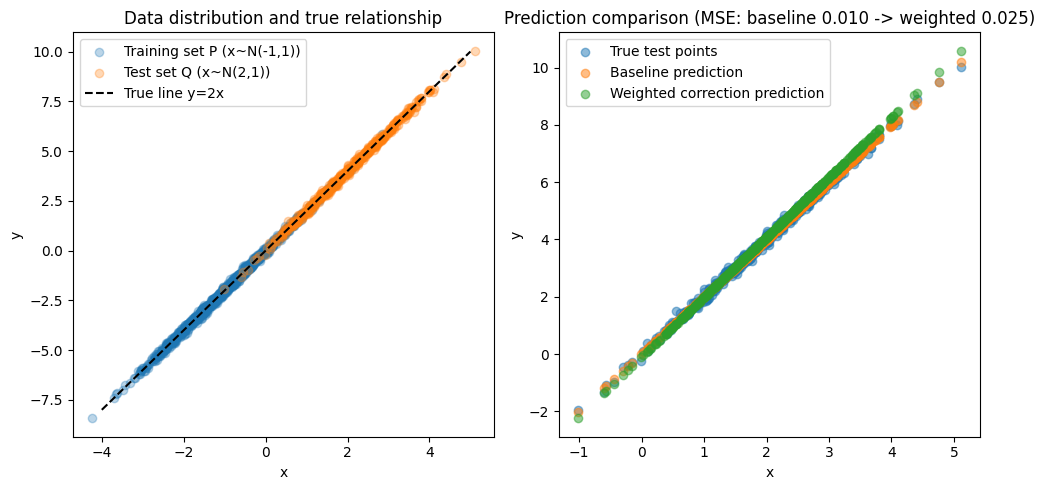


Model parameter comparison:
Ground truth: y = 2.00 * x
Baseline model: y = 0.003 + 1.996 * x
Weighted model: y = -0.111 + 2.095 * x


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

# ------------------------------
# 1. Synthetic Dataset Construction
# ------------------------------
np.random.seed(42)

# Training set P: x ~ N(-1, 1), y = 2x + noise
n_train = 1000
x_train = np.random.normal(-1, 1, size=(n_train, 1))
noise = np.random.normal(0, 0.1, size=(n_train, 1))
y_train = 2 * x_train + noise

# Test set Q: x ~ N(2, 1), y = 2x + noise (same noise level)
n_test = 500
x_test = np.random.normal(2, 1, size=(n_test, 1))
noise_test = np.random.normal(0, 0.1, size=(n_test, 1))
y_test = 2 * x_test + noise_test

print("Training set x mean: {:.2f}, Test set x mean: {:.2f}".format(x_train.mean(), x_test.mean()))
print("Training set x variance: {:.2f}, Test set x variance: {:.2f}".format(x_train.var(), x_test.var()))

# ------------------------------
# 2. Baseline Model (Ordinary Linear Regression)
# ------------------------------
baseline_model = LinearRegression()
baseline_model.fit(x_train, y_train)
y_pred_baseline = baseline_model.predict(x_test)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
print("\nBaseline model (no correction) test MSE: {:.4f}".format(mse_baseline))

# ------------------------------
# 3. Train Logistic Regression to Distinguish Training/Test Distributions
# ------------------------------
# Combine data and create labels: training set label 0, test set label 1
X_combined = np.vstack([x_train, x_test])
y_combined = np.hstack([np.zeros(n_train), np.ones(n_test)])

# Train logistic regression
lr_clf = LogisticRegression(C=1e6, solver='lbfgs')  # weak regularization
lr_clf.fit(X_combined, y_combined)

# Predict probability of belonging to test set for training samples P(test|x)
prob_test = lr_clf.predict_proba(x_train)[:, 1]  # probability of class 1

# Compute weights wi = P(test|x) / P(train|x) = p / (1-p)
weights = prob_test / (1 - prob_test)

# Optional: normalize weights to keep total sum approx n_train (does not affect weighted LS solution)
weights = weights / np.sum(weights) * n_train

print("Weight statistics: min={:.3f}, max={:.3f}, mean={:.3f}".format(weights.min(), weights.max(), weights.mean()))

# ------------------------------
# 4. Weighted Linear Regression (Manual Weighted Least Squares)
# ------------------------------
def weighted_linear_regression(X, y, weights):
    """
    X: (n_samples, n_features) design matrix (no intercept)
    y: (n_samples,)
    weights: (n_samples,) sample weights
    Returns (intercept, slope)
    """
    # Add intercept column
    X_with_intercept = np.hstack([np.ones((X.shape[0], 1)), X])
    W = np.diag(weights)
    # beta = (X^T W X)^{-1} X^T W y
    XTWX = X_with_intercept.T @ W @ X_with_intercept
    XTWy = X_with_intercept.T @ W @ y
    beta = np.linalg.solve(XTWX, XTWy)
    return beta[0], beta[1]   # intercept, slope

intercept_weighted, slope_weighted = weighted_linear_regression(x_train, y_train.ravel(), weights)

# Predict on test set using weighted model
y_pred_weighted = intercept_weighted + slope_weighted * x_test.ravel()
mse_weighted = mean_squared_error(y_test.ravel(), y_pred_weighted)
print("\nWeighted model (covariate shift corrected) test MSE: {:.4f}".format(mse_weighted))
print("Improvement: MSE reduced by {:.2f}%".format((mse_baseline - mse_weighted) / mse_baseline * 100))

# ------------------------------
# 5. Visualization
# ------------------------------
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(x_train, y_train, alpha=0.3, label='Training set P (x~N(-1,1))')
plt.scatter(x_test, y_test, alpha=0.3, label='Test set Q (x~N(2,1))')
x_line = np.linspace(-4, 5, 100)
plt.plot(x_line, 2*x_line, 'k--', label='True line y=2x')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data distribution and true relationship')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(x_test, y_test, alpha=0.5, label='True test points')
plt.scatter(x_test, y_pred_baseline, alpha=0.5, label='Baseline prediction')
plt.scatter(x_test, y_pred_weighted, alpha=0.5, label='Weighted correction prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Prediction comparison (MSE: baseline {:.3f} -> weighted {:.3f})'.format(mse_baseline, mse_weighted))
plt.legend()
plt.tight_layout()
plt.savefig('covariate_shift_correction.png')
plt.show()

# ------------------------------
# Extra: Compare fitted parameters with ground truth
# ------------------------------
print("\nModel parameter comparison:")
print("Ground truth: y = 2.00 * x")
print("Baseline model: y = {:.3f} + {:.3f} * x".format(baseline_model.intercept_[0], baseline_model.coef_[0][0]))
print("Weighted model: y = {:.3f} + {:.3f} * x".format(intercept_weighted, slope_weighted))